# 5D NLS Fokker-Planck Neural Network Solver

Variables: $(I_1, I_2, I_3, \\theta_1, \\theta_3)$

- **Data loss**: 31k nonzero-density boxes (log-normalized)  
- **PDE loss**: 100k collocation points (all 50k boxes + 50k LHS)  
- Zero-density regions constrained by physics (L†p=0), not fake data
- Add a training layer of cos, sin, 

In [1]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats.qmc import LatinHypercube
import timeit, os

pi  = np.float32(np.pi)
gam = np.float32(0.1)
T1  = np.float32(2.0)
T3  = np.float32(8.0)
I_max = 10.0

# ============================================================
# Load MC data
# ============================================================
X_boxes = np.loadtxt('NLS_FP_boxes.txt', dtype=np.float32)
Y_dens  = np.loadtxt('NLS_FP_density.txt', dtype=np.float32)

# Data loss uses only boxes with MC observations
mask_nz = Y_dens > 0
X_data = X_boxes[mask_nz]
Y_data = Y_dens[mask_nz]

# Log-normalize
Y_log = np.log(Y_data)
Y_log_mean = Y_log.mean()
Y_log_std  = Y_log.std()
Y_scaled = ((Y_log - Y_log_mean) / Y_log_std).astype(np.float32)

X_data_t = tf.convert_to_tensor(X_data, dtype=tf.float32)
Y_data_t = tf.reshape(tf.convert_to_tensor(Y_scaled, dtype=tf.float32), [-1, 1])

print(f"Data loss points: {len(X_data)} (nonzero density only)")
print(f"Zero-density boxes: {(~mask_nz).sum()} (used in PDE loss only)")
print(f"Log density: mean={Y_log_mean:.4f}, std={Y_log_std:.4f}")
print(f"Scaled Y range: [{Y_scaled.min():.2f}, {Y_scaled.max():.2f}]")

# ============================================================
# Collocation points for PDE loss:
# ALL 50k box centers (including zero-density) + 50k LHS
# Zero-density regions are covered by PDE constraint, not data
# ============================================================
N_lhs = 50000
sampler = LatinHypercube(d=5, seed=42)
lhs_raw = sampler.random(n=N_lhs).astype(np.float32)
X_lhs = np.column_stack([
    (lhs_raw[:,0] * (I_max - 0.01) + 0.01).astype(np.float32),
    (lhs_raw[:,1] * (I_max - 0.01) + 0.01).astype(np.float32),
    (lhs_raw[:,2] * (I_max - 0.01) + 0.01).astype(np.float32),
    (lhs_raw[:,3] * 2*pi - pi).astype(np.float32),
    (lhs_raw[:,4] * 2*pi - pi).astype(np.float32)])
X_colloc = np.vstack([X_lhs, X_boxes]).astype(np.float32)
X_colloc_t = tf.convert_to_tensor(X_colloc)
print(f"PDE collocation: {len(X_colloc)} ({N_lhs} LHS + {len(X_boxes)} all box centers)")

Data loss points: 35485 (nonzero density only)
Zero-density boxes: 14515 (used in PDE loss only)
Log density: mean=-10.0916, std=3.7679
Scaled Y range: [-3.92, 0.92]
PDE collocation: 100000 (50000 LHS + 50000 all box centers)


In [2]:
# ============================================================
# 5D drift and divergence 
# ============================================================
def compute_drift(x):
    I1, I2, I3 = x[...,0], x[...,1], x[...,2]
    th1, th3   = x[...,3], x[...,4]
    s1, c1 = tf.math.sin(th1), tf.math.cos(th1)
    s3, c3 = tf.math.sin(th3), tf.math.cos(th3)
    b_I1  = 4*I1*I2*s1 - 4*gam*I1*I2*(1+c1) + 4*gam*T1 - 2*gam*(I1*I1 + 2*I1*I3)
    b_I2  = -4*I2*(I1*s1 + I3*s3)
    b_I3  = 4*I3*I2*s3 - 4*gam*I3*I2*(1+c3) + 4*gam*T3 - 2*gam*(I3*I3 + 2*I1*I3)
    b_th1 = 2*(I2-I1) + 4*(I2-I1)*c1 + 4*gam*I2*s1 - 4*I3*c3
    b_th3 = 2*(I2-I3) + 4*(I2-I3)*c3 + 4*gam*I2*s3 - 4*I1*c1
    return b_I1, b_I2, b_I3, b_th1, b_th3

def compute_div_b(x):
    I1, I2, I3 = x[...,0], x[...,1], x[...,2]
    th1, th3   = x[...,3], x[...,4]
    s1, c1 = tf.math.sin(th1), tf.math.cos(th1)
    s3, c3 = tf.math.sin(th3), tf.math.cos(th3)
    # db_I1/dI1: d/dI1[4*I1*I2*s1 - 4*gam*I1*I2*(1+c1) + 4*gam*T1 - 2*gam*(I1^2+2*I1*I3)]
    #          = 4*I2*s1 - 4*gam*I2*(1+c1) - 2*gam*(2*I1+2*I3)
    db1 = 4*I2*s1 - 4*gam*I2*(1+c1) - 2*gam*(2*I1 + 2*I3)
    db2 = -4*(I1*s1 + I3*s3)
    db3 = 4*I2*s3 - 4*gam*I2*(1+c3) - 2*gam*(2*I3 + 2*I1)
    db4 = -4*(I2-I1)*s1 + 4*gam*I2*c1
    db5 = -4*(I2-I3)*s3 + 4*gam*I2*c3
    return db1 + db2 + db3 + db4 + db5

In [3]:
# ============================================================
# Neural network: 7→32→256→256→128→64→16→1 (with periodic encoding)
# ============================================================
init = tf.keras.initializers.GlorotUniform()
reg  = tf.keras.regularizers.l2(1e-4)

inp = tf.keras.layers.Input(shape=(5,))

# Periodic encoding: (I1,I2,I3,θ1,θ3) → (I1,I2,I3,cosθ1,sinθ1,cosθ3,sinθ3)
@tf.keras.utils.register_keras_serializable()
def periodic_encode(x):
    I_vars = x[:, :3]
    cos_th1 = tf.math.cos(x[:, 3:4])
    sin_th1 = tf.math.sin(x[:, 3:4])
    cos_th3 = tf.math.cos(x[:, 4:5])
    sin_th3 = tf.math.sin(x[:, 4:5])
    return tf.concat([I_vars, cos_th1, sin_th1, cos_th3, sin_th3], axis=-1)

encoded = tf.keras.layers.Lambda(periodic_encode)(inp)

h = tf.keras.layers.Dense(32,  activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(encoded)
h = tf.keras.layers.Dense(256, activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(h)
h = tf.keras.layers.Dense(256, activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(h)
h = tf.keras.layers.Dense(128, activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(h)
h = tf.keras.layers.Dense(64,  activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(h)
h = tf.keras.layers.Dense(16,  activation='sigmoid', kernel_initializer=init, kernel_regularizer=reg)(h)
out = tf.keras.layers.Dense(1)(h)

model = tf.keras.models.Model(inp, out)
model.summary()

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3)
batch_size = 64

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda (Lambda)                 │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │         8,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 116,705 (455.88 KB)

 Trainable params: 116,705 (455.88 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# ============================================================
# Training step: log-normalized, single optimizer
# NN outputs u(x), density p = exp(σ·u + μ)
# ============================================================
Y_mu  = tf.constant(Y_log_mean, dtype=tf.float32)
Y_sig = tf.constant(Y_log_std,  dtype=tf.float32)

@tf.function
def train_step(X_b, Y_b, X_c, w_data=1.0, w_pde=0.1):
    with tf.GradientTape(persistent=True) as tp:
        tp.watch(X_c)

        # --- data loss: log-normalized ---
        pred = model(X_b, training=True)
        loss_data = tf.reduce_mean(tf.square(Y_b - pred))

        # --- FP residual loss ---
        u = model(X_c, training=True)[...,0]
        p = tf.exp(Y_sig * u + Y_mu)
        gp = tp.gradient(tf.reduce_sum(p), X_c)
        pI1, pI2, pI3, pt1, pt3 = gp[...,0], gp[...,1], gp[...,2], gp[...,3], gp[...,4]
        pI1I1 = tp.gradient(pI1, X_c)[...,0]
        pI3I3 = tp.gradient(pI3, X_c)[...,2]
        pt1t1 = tp.gradient(pt1, X_c)[...,3]
        pt3t3 = tp.gradient(pt3, X_c)[...,4]
        I1 = tf.math.maximum(X_c[...,0], 1e-6)
        I3 = tf.math.maximum(X_c[...,2], 1e-6)
        diff = 4*gam*T1*I1*pI1I1 + 4*gam*T3*I3*pI3I3 + 4*gam*T1/I1*pt1t1 + 4*gam*T3/I3*pt3t3
        bI1,bI2,bI3,bt1,bt3 = compute_drift(X_c)
        adv = (-bI1+8*gam*T1)*pI1 + (-bI2)*pI2 + (-bI3+8*gam*T3)*pI3 + (-bt1)*pt1 + (-bt3)*pt3
        fp = diff + adv - compute_div_b(X_c)*p
        loss_pde = tf.reduce_mean(tf.square(fp / (p + 1e-10)))

        # --- combined ---
        loss = w_data * loss_data + w_pde * loss_pde

    grads = tp.gradient(loss, model.trainable_weights)
    optimizer.apply_gradients(zip(grads, model.trainable_weights))
    return loss_data, loss_pde

In [5]:
# ============================================================
# Phase 1: Pre-train on MC data only (80 epochs)
# Only nonzero-density boxes — log-normalized targets
# ============================================================
os.makedirs('h5_files', exist_ok=True)
optimizer.learning_rate.assign(1e-3)
pre_epochs = 80

start = timeit.default_timer()
for epoch in range(pre_epochs):
    n_bat = max(1, len(X_data) // batch_size)
    tot = 0.0
    for _ in range(n_bat):
        idx = np.random.randint(len(X_data), size=batch_size)
        with tf.GradientTape() as t:
            loss = tf.reduce_mean(tf.square(tf.gather(Y_data_t, idx) - model(tf.gather(X_data_t, idx), training=True)))
        optimizer.apply_gradients(zip(t.gradient(loss, model.trainable_weights), model.trainable_weights))
        tot += loss.numpy()
    if (epoch+1) % 10 == 0:
        print(f"Pre-train {epoch+1:3d}/{pre_epochs}  loss = {tot/n_bat:.6e}")

print(f"Pre-training time: {timeit.default_timer()-start:.1f}s")
model.save('h5_files/pretrained.keras')

Pre-train  10/80  loss = 2.148585e-02
Pre-train  20/80  loss = 1.644704e-02
Pre-train  30/80  loss = 1.351888e-02
Pre-train  40/80  loss = 1.230388e-02
Pre-train  50/80  loss = 1.115841e-02
Pre-train  60/80  loss = 1.079485e-02
Pre-train  70/80  loss = 1.164643e-02
Pre-train  80/80  loss = 1.037394e-02
Pre-training time: 641.2s


In [6]:
# ============================================================
# Phase 2: Joint training (500 epochs)
# Data loss: 31k nonzero boxes (log-normalized)
# PDE loss: 100k collocation (all boxes + LHS)
# ============================================================
optimizer.learning_rate.assign(1e-3)
joint_epochs = 500

start = timeit.default_timer()
for epoch in range(joint_epochs):
    # LR decay
    if epoch == 150:
        optimizer.learning_rate.assign(5e-4)
        print(">> LR -> 5e-4")
    elif epoch == 300:
        optimizer.learning_rate.assign(2e-4)
        print(">> LR -> 2e-4")

    # Ramp PDE weight: 0 for first 20 epochs, then linearly to 0.5 over 150ep
    if epoch < 20:
        w_pde = 0.0
    else:
        w_pde = min(0.5, 0.5 * (epoch - 20) / 150)

    n_bat = max(1, len(X_data) // batch_size)
    tl1, tl2 = 0.0, 0.0
    for _ in range(n_bat):
        idx_d = np.random.randint(len(X_data), size=batch_size)
        idx_c = np.random.randint(len(X_colloc), size=batch_size)
        l1, l2 = train_step(tf.gather(X_data_t, idx_d), tf.gather(Y_data_t, idx_d),
                            tf.gather(X_colloc_t, idx_c),
                            w_data=1.0, w_pde=w_pde)
        tl1 += l1.numpy(); tl2 += l2.numpy()

    if (epoch+1) % 50 == 0 or epoch == 0:
        model.save(f'h5_files/FC_{epoch}.keras')
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Joint {epoch+1:4d}/{joint_epochs}  w_pde={w_pde:.3f}  L_data={tl1/n_bat:.4e}  L_FP={tl2/n_bat:.4e}")

print(f"Joint training time: {timeit.default_timer()-start:.1f}s")
model.save('h5_files/final.keras')

Joint    1/500  w_pde=0.000  L_data=1.0866e-02  L_FP=2.5953e+02
Joint   10/500  w_pde=0.000  L_data=1.0106e-02  L_FP=2.2341e+02
Joint   20/500  w_pde=0.000  L_data=1.0060e-02  L_FP=2.3345e+02
Joint   30/500  w_pde=0.030  L_data=1.2216e-01  L_FP=6.3372e+00
Joint   40/500  w_pde=0.063  L_data=1.5743e-01  L_FP=3.8400e+00
Joint   50/500  w_pde=0.097  L_data=1.9071e-01  L_FP=3.0847e+00
Joint   60/500  w_pde=0.130  L_data=2.1093e-01  L_FP=2.6149e+00
Joint   70/500  w_pde=0.163  L_data=2.1014e-01  L_FP=2.1022e+00
Joint   80/500  w_pde=0.197  L_data=2.2663e-01  L_FP=1.9695e+00
Joint   90/500  w_pde=0.230  L_data=2.3119e-01  L_FP=1.7492e+00
Joint  100/500  w_pde=0.263  L_data=2.3139e-01  L_FP=1.5314e+00
Joint  110/500  w_pde=0.297  L_data=2.4476e-01  L_FP=1.5084e+00
Joint  120/500  w_pde=0.330  L_data=2.3706e-01  L_FP=1.3341e+00
Joint  130/500  w_pde=0.363  L_data=2.5357e-01  L_FP=1.2889e+00
Joint  140/500  w_pde=0.397  L_data=2.4911e-01  L_FP=1.1593e+00
Joint  150/500  w_pde=0.430  L_data=2.53

RMSE (log-scaled): 0.418714
RMSE (density):    2.44e-04


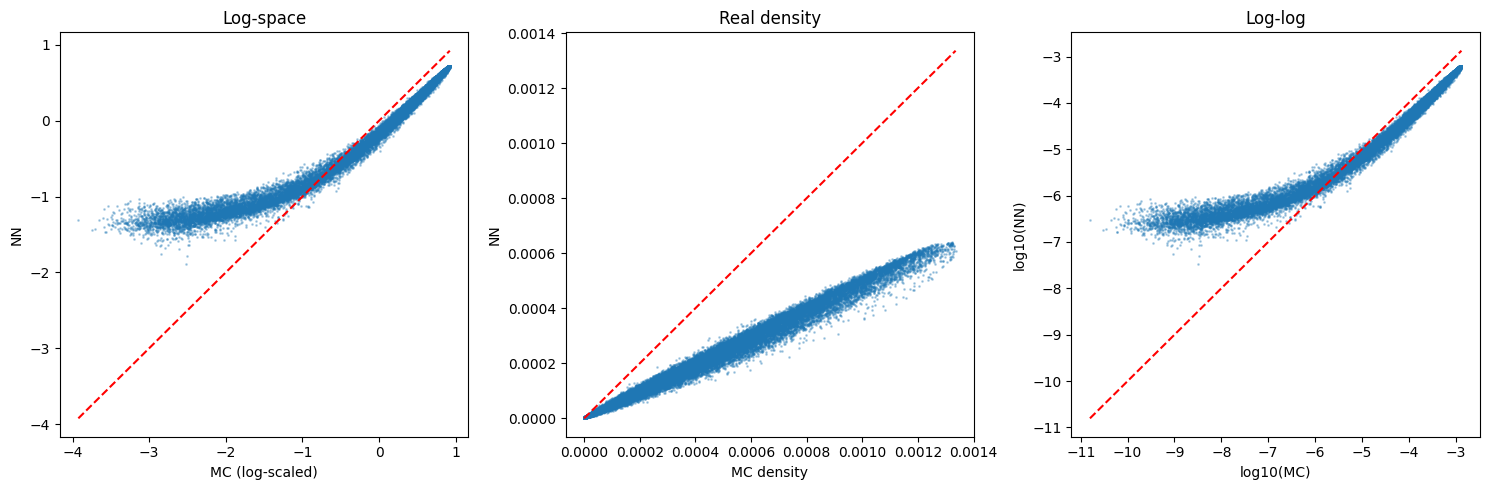

In [7]:
# ============================================================
# Evaluate
# ============================================================
Z_pred = model(X_data_t, training=False).numpy().flatten()
Z_true = Y_data_t.numpy().flatten()
Y_pred = np.exp(Y_log_std * Z_pred + Y_log_mean)
Y_true = Y_data

print(f"RMSE (log-scaled): {np.sqrt(np.mean((Z_true-Z_pred)**2)):.6f}")
print(f"RMSE (density):    {np.sqrt(np.mean((Y_true-Y_pred)**2)):.2e}")

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].scatter(Z_true, Z_pred, s=1, alpha=0.3)
mn, mx = Z_true.min(), Z_true.max()
axes[0].plot([mn,mx],[mn,mx],'r--'); axes[0].set_xlabel('MC (log-scaled)'); axes[0].set_ylabel('NN'); axes[0].set_title('Log-space')

axes[1].scatter(Y_true, Y_pred, s=1, alpha=0.3)
axes[1].plot([0,Y_true.max()],[0,Y_true.max()],'r--'); axes[1].set_xlabel('MC density'); axes[1].set_ylabel('NN'); axes[1].set_title('Real density')

axes[2].scatter(np.log10(Y_true), np.log10(np.maximum(Y_pred,1e-12)), s=1, alpha=0.3)
mn, mx = np.log10(Y_true.min()), np.log10(Y_true.max())
axes[2].plot([mn,mx],[mn,mx],'r--'); axes[2].set_xlabel('log10(MC)'); axes[2].set_ylabel('log10(NN)'); axes[2].set_title('Log-log')
plt.tight_layout(); plt.show()

FP residual on 5000 test points:
  mean |residual/p|: 0.3810
  median:            0.2360
  90th percentile:   0.8698


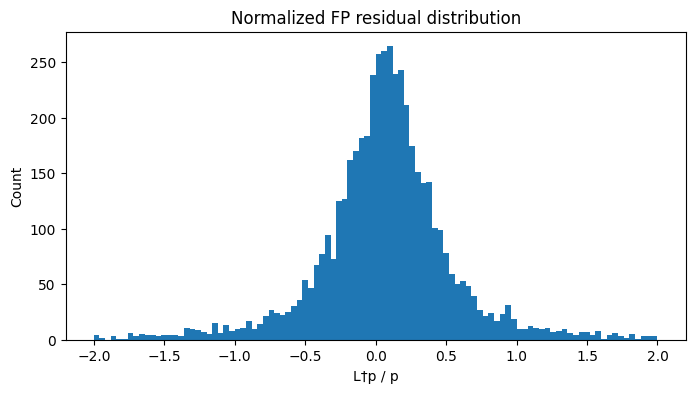

In [8]:
# ============================================================
# FP residual diagnostic
# ============================================================
N_test = 5000
idx_test = np.random.randint(len(X_colloc), size=N_test)
X_test = tf.constant(X_colloc[idx_test], dtype=tf.float32)

with tf.GradientTape(persistent=True) as tp:
    tp.watch(X_test)
    p = tf.exp(Y_sig * model(X_test, training=False)[...,0] + Y_mu)
    gp = tp.gradient(tf.reduce_sum(p), X_test)
    pI1I1 = tp.gradient(gp[...,0], X_test)[...,0]
    pI3I3 = tp.gradient(gp[...,2], X_test)[...,2]
    pt1t1 = tp.gradient(gp[...,3], X_test)[...,3]
    pt3t3 = tp.gradient(gp[...,4], X_test)[...,4]
    I1 = tf.math.maximum(X_test[...,0], 1e-6); I3 = tf.math.maximum(X_test[...,2], 1e-6)
    diff = 4*gam*T1*I1*pI1I1 + 4*gam*T3*I3*pI3I3 + 4*gam*T1/I1*pt1t1 + 4*gam*T3/I3*pt3t3
    bI1,bI2,bI3,bt1,bt3 = compute_drift(X_test)
    adv = (-bI1+8*gam*T1)*gp[...,0] + (-bI2)*gp[...,1] + (-bI3+8*gam*T3)*gp[...,2] + (-bt1)*gp[...,3] + (-bt3)*gp[...,4]
    fp = diff + adv - compute_div_b(X_test)*p
    rel_res = (fp / (p + 1e-10)).numpy()

print(f"FP residual on {N_test} test points:")
print(f"  mean |residual/p|: {np.mean(np.abs(rel_res)):.4f}")
print(f"  median:            {np.median(np.abs(rel_res)):.4f}")
print(f"  90th percentile:   {np.percentile(np.abs(rel_res), 90):.4f}")

plt.figure(figsize=(8,4))
plt.hist(rel_res, bins=100, range=(-2,2))
plt.xlabel('L†p / p'); plt.ylabel('Count'); plt.title('Normalized FP residual distribution')
plt.show()

# Non-equilibrum

In [11]:
# Load non-eq model and data statistics
@tf.keras.utils.register_keras_serializable()
def periodic_encode(x):
    I_vars = x[:, :3]
    cos_th1 = tf.math.cos(x[:, 3:4])
    sin_th1 = tf.math.sin(x[:, 3:4])
    cos_th3 = tf.math.cos(x[:, 4:5])
    sin_th3 = tf.math.sin(x[:, 4:5])
    return tf.concat([I_vars, cos_th1, sin_th1, cos_th3, sin_th3], axis=-1)

model_neq = tf.keras.models.load_model('h5_files/final.keras')

Y_dens_neq = np.loadtxt('NLS_FP_density.txt', dtype=np.float32)
Y_log_neq = np.log(Y_dens_neq[Y_dens_neq > 0])
Y_log_mean_neq = Y_log_neq.mean()
Y_log_std_neq = Y_log_neq.std()
print(f"Non-eq: mean={Y_log_mean_neq:.4f}, std={Y_log_std_neq:.4f}")

ValueError: File not found: filepath=h5_files/final.keras. Please ensure the file is an accessible `.keras` zip file.

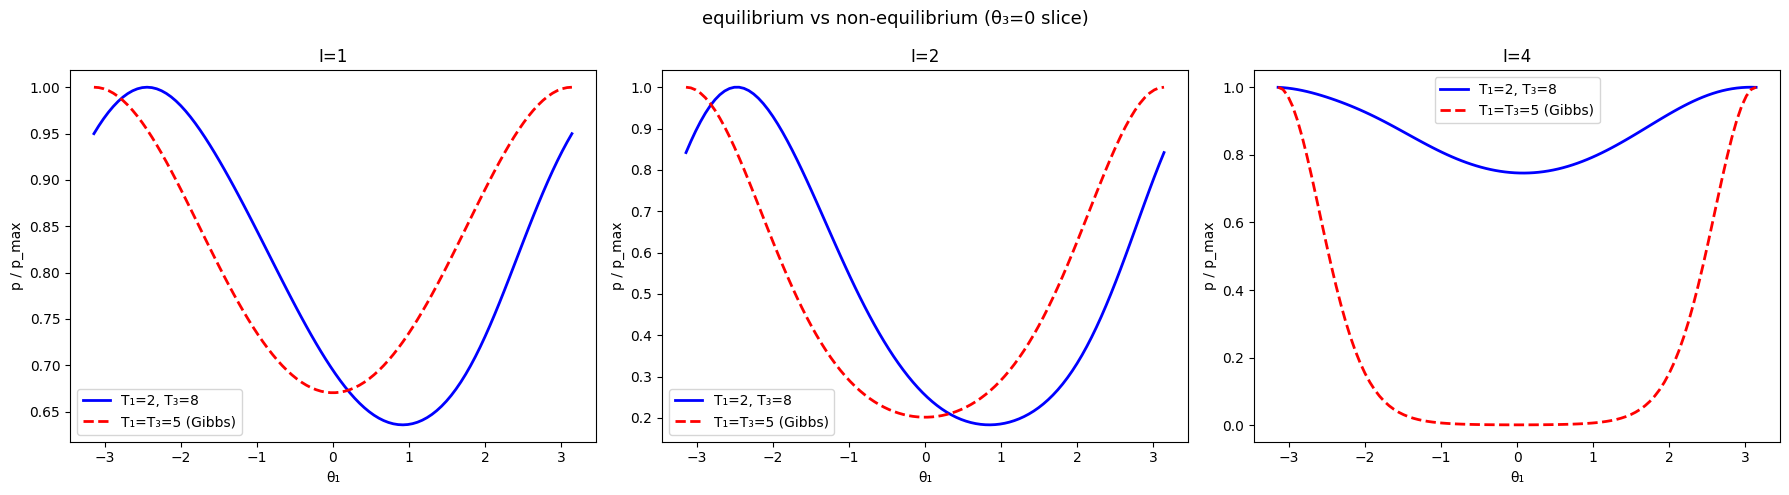

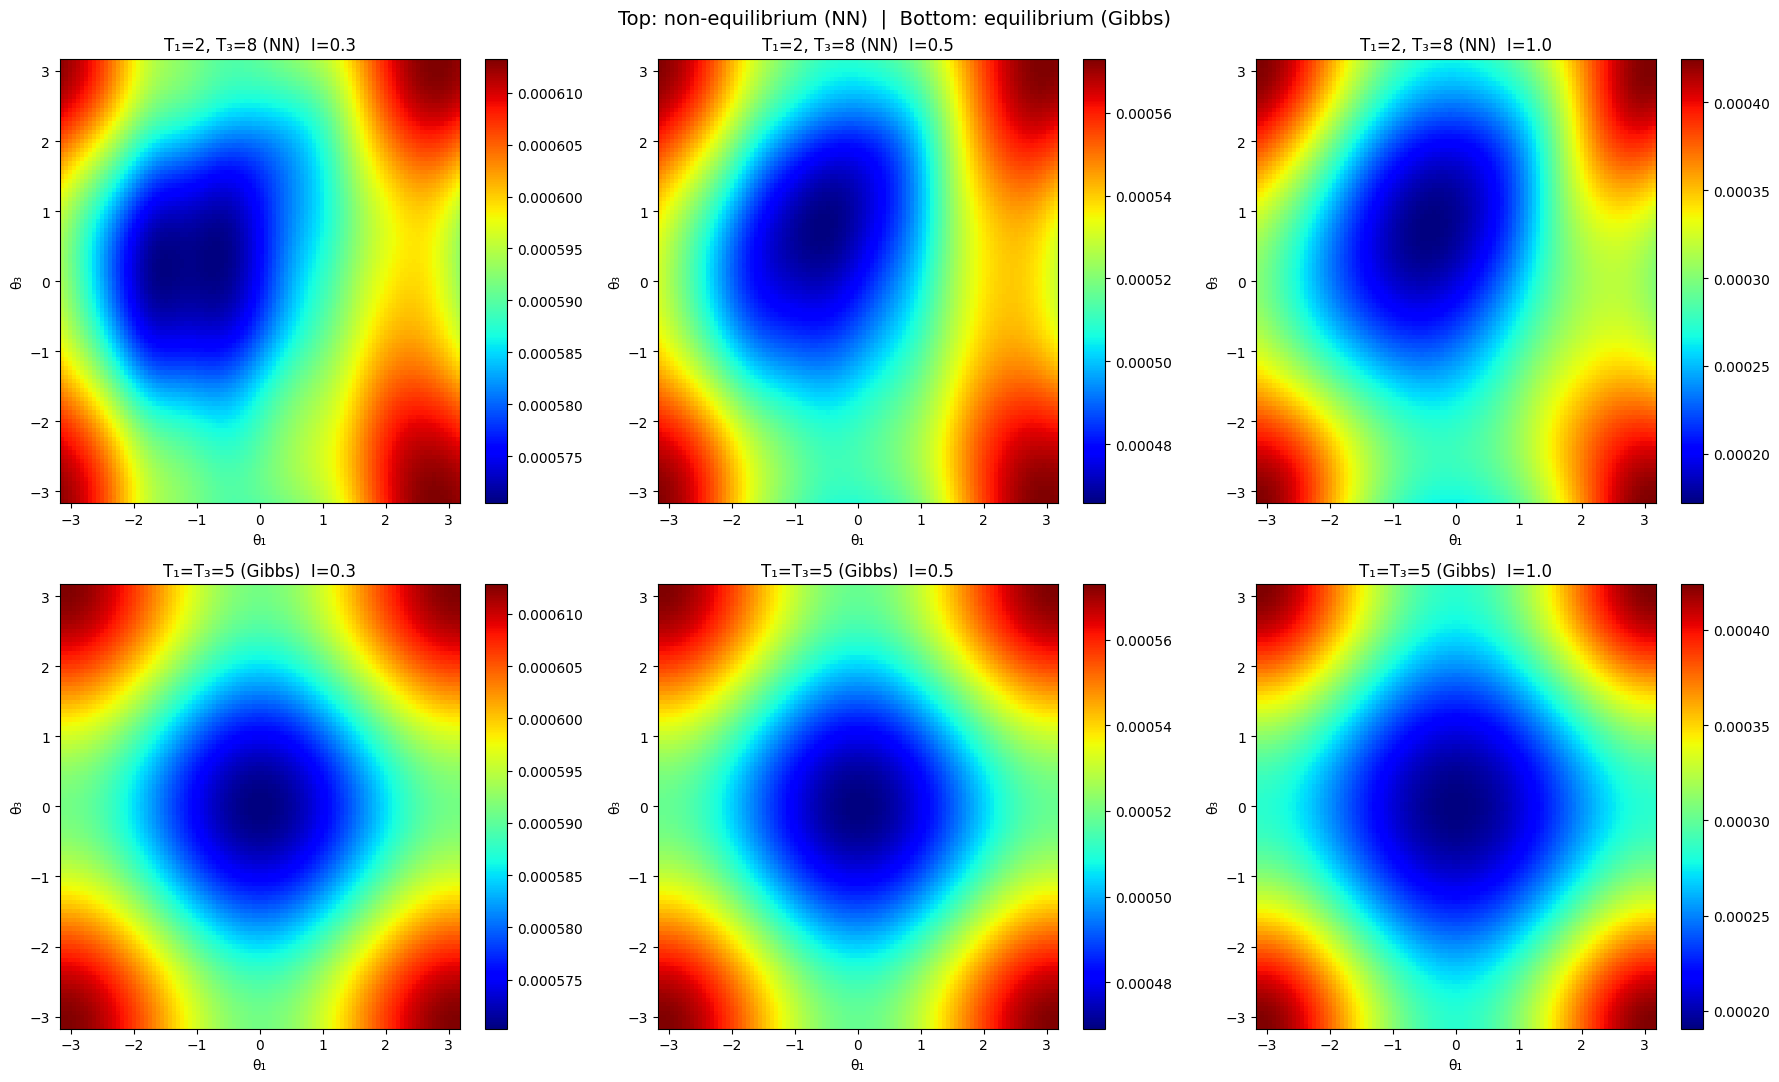

In [12]:
# Non-equilibrium analysis plots
N = 100
theta = np.linspace(-np.pi, np.pi, N, dtype=np.float32)
TH1, TH3 = np.meshgrid(theta, theta)

# --- 1D angle comparison ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (I_val, title_I) in enumerate([(1.0,'I=1'), (2.0,'I=2'), (4.0,'I=4')]):
    sl = np.column_stack([np.full(N*N, I_val, dtype=np.float32),
                          np.full(N*N, I_val, dtype=np.float32),
                          np.full(N*N, I_val, dtype=np.float32),
                          TH1.ravel(), TH3.ravel()])
    P_neq = np.exp(Y_log_std_neq * model_neq(sl, training=False).numpy().flatten() + Y_log_mean_neq).reshape(N, N)
    mid = N // 2
    axes[idx].plot(theta, P_neq[:, mid] / P_neq[:, mid].max(), 'b-', linewidth=2, label='T₁=2, T₃=8')
    M = 3*I_val
    H = M**2 - 1.5*I_val**2 + 2*I_val**2*np.cos(theta) + 2*I_val**2
    P_eq = np.exp(-H / 10.0)
    axes[idx].plot(theta, P_eq / P_eq.max(), 'r--', linewidth=2, label='T₁=T₃=5 (Gibbs)')
    axes[idx].set_xlabel('θ₁'); axes[idx].set_ylabel('p / p_max')
    axes[idx].set_title(title_I); axes[idx].legend()
plt.suptitle('equilibrium vs non-equilibrium (θ₃=0 slice)', fontsize=13)
plt.tight_layout(); plt.show()

# --- 2D mesh comparison ---
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
for idx, I_val in enumerate([0.3, 0.5, 1.0]):
    sl = np.column_stack([np.full(N*N, I_val, dtype=np.float32),
                          np.full(N*N, I_val, dtype=np.float32),
                          np.full(N*N, I_val, dtype=np.float32),
                          TH1.ravel(), TH3.ravel()])
    P_neq = np.exp(Y_log_std_neq * model_neq(sl, training=False).numpy().flatten() + Y_log_mean_neq).reshape(N, N)
    M = 3*I_val
    H = M**2 - 1.5*I_val**2 + 2*I_val**2*np.cos(TH1) + 2*I_val**2*np.cos(TH3)
    P_eq = np.exp(-H / 10.0)
    P_eq *= P_neq.sum() / P_eq.sum()
    im0 = axes[0, idx].pcolormesh(theta, theta, P_neq, cmap='jet', shading='auto')
    axes[0, idx].set_title(f'T₁=2, T₃=8 (NN)  I={I_val}')
    axes[0, idx].set_xlabel('θ₁'); axes[0, idx].set_ylabel('θ₃')
    plt.colorbar(im0, ax=axes[0, idx])
    im1 = axes[1, idx].pcolormesh(theta, theta, P_eq, cmap='jet', shading='auto')
    axes[1, idx].set_title(f'T₁=T₃=5 (Gibbs)  I={I_val}')
    axes[1, idx].set_xlabel('θ₁'); axes[1, idx].set_ylabel('θ₃')
    plt.colorbar(im1, ax=axes[1, idx])
plt.suptitle('Top: non-equilibrium (NN)  |  Bottom: equilibrium (Gibbs)', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Non-equilibrium vs equilibrium: angle distribution comparison
# Uses current model (non-eq, trained in cells 5-6)

N = 100
theta = np.linspace(-np.pi, np.pi, N, dtype=np.float32)
TH1, TH3 = np.meshgrid(theta, theta)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, (I_val, title_I) in enumerate([(1.0,'I=1'), (2.0,'I=2'), (4.0,'I=4')]):
    sl = np.column_stack([np.full(N*N, I_val, dtype=np.float32),
                          np.full(N*N, I_val, dtype=np.float32),
                          np.full(N*N, I_val, dtype=np.float32),
                          TH1.ravel(), TH3.ravel()])
    
    # Non-equilibrium (current model, T1=2 T3=8)
    P_neq = np.exp(Y_log_std * model_neq(sl, training=False).numpy().flatten() + Y_log_mean).reshape(N, N)
    
    # 1D cuts: p vs θ1 at θ3=0
    mid = N // 2
    axes[idx].plot(theta, P_neq[:, mid] / P_neq[:, mid].max(), 'b-', linewidth=2, label='T₁=2, T₃=8')
    
    # Gibbs (T1=T3=5 analytic)
    M = 3*I_val
    H = M**2 - 1.5*I_val**2 + 2*I_val**2*np.cos(theta) + 2*I_val**2
    P_eq = np.exp(-H / 10.0)
    axes[idx].plot(theta, P_eq / P_eq.max(), 'r--', linewidth=2, label='T₁=T₃=5 (Gibbs)')
    
    axes[idx].set_xlabel('θ₁'); axes[idx].set_ylabel('p / p_max')
    axes[idx].set_title(title_I); axes[idx].legend()

plt.suptitle('equilibrium vs non-equilibrium (θ₃=0 slice)', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# 2D mesh: equilibrium vs non-equilibrium
# Uses current model (non-eq) vs Gibbs analytic (eq)

N = 100
theta = np.linspace(-np.pi, np.pi, N, dtype=np.float32)
TH1, TH3 = np.meshgrid(theta, theta)

fig, axes = plt.subplots(2, 3, figsize=(18, 11))

for idx, I_val in enumerate([0.3, 0.5, 1.0]):
    sl = np.column_stack([np.full(N*N, I_val, dtype=np.float32),
                          np.full(N*N, I_val, dtype=np.float32),
                          np.full(N*N, I_val, dtype=np.float32),
                          TH1.ravel(), TH3.ravel()])
    
    # Non-equilibrium (current model T1=2, T3=8)
    P_neq = np.exp(Y_log_std * model_neq(sl, training=False).numpy().flatten() + Y_log_mean).reshape(N, N)
    
    # Gibbs equilibrium (analytic T1=T3=5)
    M = 3*I_val
    H = M**2 - 1.5*I_val**2 + 2*I_val**2*np.cos(TH1) + 2*I_val**2*np.cos(TH3)
    P_eq = np.exp(-H / 10.0)
    P_eq *= P_neq.sum() / P_eq.sum()
    
    im0 = axes[0, idx].pcolormesh(theta, theta, P_neq, cmap='jet', shading='auto')
    axes[0, idx].set_title(f'T₁=2, T₃=8 (NN)  I={I_val}')
    axes[0, idx].set_xlabel('θ₁'); axes[0, idx].set_ylabel('θ₃')
    plt.colorbar(im0, ax=axes[0, idx])
    
    im1 = axes[1, idx].pcolormesh(theta, theta, P_eq, cmap='jet', shading='auto')
    axes[1, idx].set_title(f'T₁=T₃=5 (Gibbs)  I={I_val}')
    axes[1, idx].set_xlabel('θ₁'); axes[1, idx].set_ylabel('θ₃')
    plt.colorbar(im1, ax=axes[1, idx])

plt.suptitle('Top: non-equilibrium (NN)  |  Bottom: equilibrium (Gibbs)', fontsize=14)
plt.tight_layout(); plt.show()

In [ ]:
# Symmetry breaking check: p(θ1, θ3) vs p(θ3, θ1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
I_val = 2.0
sl = np.column_stack([np.full(N*N, I_val, dtype=np.float32),
                      np.full(N*N, I_val, dtype=np.float32),
                      np.full(N*N, I_val, dtype=np.float32),
                      TH1.ravel(), TH3.ravel()])
P = np.exp(Y_log_std * model(sl, training=False).numpy().flatten() + Y_log_mean).reshape(N, N)

im0 = axes[0].pcolormesh(theta, theta, P, cmap='jet', shading='auto')
axes[0].set_title('p(θ₁, θ₃)'); axes[0].set_xlabel('θ₁'); axes[0].set_ylabel('θ₃')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(theta, theta, P.T, cmap='jet', shading='auto')
axes[1].set_title('p(θ₃, θ₁) [transposed]'); axes[1].set_xlabel('θ₁'); axes[1].set_ylabel('θ₃')
plt.colorbar(im1, ax=axes[1])

asym = (P - P.T) / (P + P.T + 1e-15)
im2 = axes[2].pcolormesh(theta, theta, asym, cmap='RdBu_r', shading='auto', vmin=-0.15, vmax=0.15)
axes[2].set_title('Asymmetry: (p − pᵀ)/(p + pᵀ)'); axes[2].set_xlabel('θ₁'); axes[2].set_ylabel('θ₃')
plt.colorbar(im2, ax=axes[2])

plt.suptitle(f'I₁=I₂=I₃={I_val} (T₁=2, T₃=8)', fontsize=13)
plt.tight_layout(); plt.show()
print(f"Max asymmetry: {np.abs(asym).max():.2%}")
print(f"Mean asymmetry: {np.abs(asym).mean():.2%}")

In [ ]:
# 1D marginals: p vs θ1 and p vs θ3 on same plot
# If T1≠T3, these two curves should differ
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for idx, I_val in enumerate([1.0, 2.0, 4.0]):
    # Integrate over θ3 to get marginal in θ1
    p_vs_th1 = np.zeros(N)
    p_vs_th3 = np.zeros(N)
    for j in range(N):
        # Fix θ3=theta[j], sweep θ1
        sl1 = np.column_stack([np.full(N, I_val, dtype=np.float32),
                               np.full(N, I_val, dtype=np.float32),
                               np.full(N, I_val, dtype=np.float32),
                               theta, np.full(N, theta[j], dtype=np.float32)])
        p_vs_th1 += np.exp(Y_log_std * model(sl1, training=False).numpy().flatten() + Y_log_mean)
        # Fix θ1=theta[j], sweep θ3
        sl3 = np.column_stack([np.full(N, I_val, dtype=np.float32),
                               np.full(N, I_val, dtype=np.float32),
                               np.full(N, I_val, dtype=np.float32),
                               np.full(N, theta[j], dtype=np.float32), theta])
        p_vs_th3 += np.exp(Y_log_std * model(sl3, training=False).numpy().flatten() + Y_log_mean)
    
    axes[idx].plot(theta, p_vs_th1/p_vs_th1.max(), 'b-', linewidth=2, label='marginal over θ₃ → p(θ₁)')
    axes[idx].plot(theta, p_vs_th3/p_vs_th3.max(), 'r--', linewidth=2, label='marginal over θ₁ → p(θ₃)')
    axes[idx].set_xlabel('θ'); axes[idx].set_ylabel('p / p_max')
    axes[idx].set_title(f'I={I_val}'); axes[idx].legend()

plt.suptitle('θ₁ vs θ₃ marginals (T₁=2 ≠ T₃=8)', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# Check I1 vs I3 asymmetry quantitatively
N = 100
I_range = np.linspace(0.1, 8.0, N, dtype=np.float32)

# Marginal: integrate over I2, θ1, θ3 at each (I1, I3)
# Quick version: just a few I2 values
p_I1 = np.zeros(N)  # marginal over everything except I1
p_I3 = np.zeros(N)  # marginal over everything except I3

N_th = 10
th_vals = np.linspace(-np.pi, np.pi, N_th, dtype=np.float32)
TH1_m, TH3_m = np.meshgrid(th_vals, th_vals)

for I2_val in [0.5, 1.0, 2.0, 3.0]:
    for i, I_val in enumerate(I_range):
        # p(I1=I_val), integrate over I3=I2_val, angles
        pts1 = np.column_stack([
            np.full(N_th*N_th, I_val, dtype=np.float32),
            np.full(N_th*N_th, I2_val, dtype=np.float32),
            np.full(N_th*N_th, I2_val, dtype=np.float32),
            TH1_m.ravel().astype(np.float32),
            TH3_m.ravel().astype(np.float32)])
        p_I1[i] += np.exp(Y_log_std * model(pts1, training=False).numpy().flatten() + Y_log_mean).mean()
        
        # p(I3=I_val), integrate over I1=I2_val, angles
        pts3 = np.column_stack([
            np.full(N_th*N_th, I2_val, dtype=np.float32),
            np.full(N_th*N_th, I2_val, dtype=np.float32),
            np.full(N_th*N_th, I_val, dtype=np.float32),
            TH1_m.ravel().astype(np.float32),
            TH3_m.ravel().astype(np.float32)])
        p_I3[i] += np.exp(Y_log_std * model(pts3, training=False).numpy().flatten() + Y_log_mean).mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(I_range, p_I1/p_I1.max(), 'b-', linewidth=2, label='p(I₁) [T₁=2, cold]')
axes[0].plot(I_range, p_I3/p_I3.max(), 'r--', linewidth=2, label='p(I₃) [T₃=8, hot]')
axes[0].set_xlabel('I'); axes[0].set_ylabel('marginal density (normalized)')
axes[0].set_title('I₁ vs I₃ marginals'); axes[0].legend()

axes[1].plot(I_range, p_I1/p_I3, 'k-', linewidth=2)
axes[1].axhline(1, color='r', linestyle='--')
axes[1].set_xlabel('I'); axes[1].set_ylabel('p(I₁) / p(I₃)')
axes[1].set_title('Ratio (=1 if symmetric)'); axes[1].set_ylim(0, 3)
plt.suptitle('Action marginals: T₁=2 vs T₃=8', fontsize=13)
plt.tight_layout(); plt.show()

In [ ]:
# Phase locking: measure actual peak position vs theory
gamma = 0.1
theta0_theory = np.arcsin((np.sqrt(4*gamma**2 + 3) - gamma) / (2*(gamma**2 + 1)))

theta = np.linspace(-np.pi, np.pi, 500, dtype=np.float32)
print("Phase locking peak position (θ₁ at θ₃=0):")
print(f"{'I':>5s}  {'NN peak':>10s}  {'Gibbs peak':>10s}  {'Shift':>10s}")

for I_val in [0.5, 1.0, 2.0, 3.0, 4.0, 5.0]:
    sl = np.column_stack([np.full(500, I_val, dtype=np.float32),
                          np.full(500, I_val, dtype=np.float32),
                          np.full(500, I_val, dtype=np.float32),
                          theta, np.zeros(500, dtype=np.float32)])
    P_nn = np.exp(Y_log_std * model(sl, training=False).numpy().flatten() + Y_log_mean)
    nn_peak = theta[np.argmin(P_nn)]
    gibbs_min = 0.0
    print(f"{I_val:5.1f}  {np.degrees(nn_peak):+8.1f}°  {np.degrees(gibbs_min):+8.1f}°  {np.degrees(nn_peak - gibbs_min):+8.1f}°")

print(f"\nTheory θ₀ (eq 4.7) = {np.degrees(theta0_theory):.1f}° (in Region IB convention)")

In [ ]:
# θ₃ flatter than θ₁: quantify width ratio
N = 100
theta = np.linspace(-np.pi, np.pi, N, dtype=np.float32)
TH1_m, TH3_m = np.meshgrid(
    np.linspace(-np.pi, np.pi, 20, dtype=np.float32),
    np.linspace(-np.pi, np.pi, 20, dtype=np.float32))

print("Angular width (std of marginal distribution):")
print(f"{'I':>5s}  {'σ(θ₁)':>8s}  {'σ(θ₃)':>8s}  {'σ₃/σ₁':>8s}  {'√(T₃/T₁)':>10s}")

for I_val in [0.5, 1.0, 2.0, 3.0, 4.0]:
    p_th1 = np.zeros(N)
    p_th3 = np.zeros(N)
    for j in range(20):
        for k in range(20):
            sl1 = np.column_stack([np.full(N, I_val, dtype=np.float32),
                                   np.full(N, I_val, dtype=np.float32),
                                   np.full(N, I_val, dtype=np.float32),
                                   theta,
                                   np.full(N, TH3_m[j,k], dtype=np.float32)])
            p_th1 += np.exp(Y_log_std * model(sl1, training=False).numpy().flatten() + Y_log_mean)
            sl3 = np.column_stack([np.full(N, I_val, dtype=np.float32),
                                   np.full(N, I_val, dtype=np.float32),
                                   np.full(N, I_val, dtype=np.float32),
                                   np.full(N, TH1_m[j,k], dtype=np.float32),
                                   theta])
            p_th3 += np.exp(Y_log_std * model(sl3, training=False).numpy().flatten() + Y_log_mean)
    p1 = p_th1 / p_th1.sum(); p3 = p_th3 / p_th3.sum()
    dth = theta[1] - theta[0]
    R1 = np.abs(np.sum(p1 * np.exp(1j * theta)) * dth)
    R3 = np.abs(np.sum(p3 * np.exp(1j * theta)) * dth)
    std1 = np.sqrt(-2 * np.log(max(R1, 1e-10)))
    std3 = np.sqrt(-2 * np.log(max(R3, 1e-10)))
    print(f"{I_val:5.1f}  {std1:8.3f}  {std3:8.3f}  {std3/std1:8.3f}  {np.sqrt(8/2):10.3f}")

print(f"\nTheory: σ₃/σ₁ ≈ √(T₃/T₁) = √4 = {np.sqrt(4):.3f} (from eq 3.4 noise scaling)")

In [ ]:

# dI2 = -4*I2*(I1*sin(θ1) + I3*sin(θ3)) dt   (no noise on mode 2)
# Steady state: <dI2/dt> = 0 since mode 2 has NO noise, NO dissipation
# So: <I2*(I1*sin(θ1) + I3*sin(θ3))> = 0

w = Y[mask]
flux = np.sum(I2 * (I1*np.sin(th1) + I3*np.sin(th3)) * w) / np.sum(w)
flux_12 = np.sum(I2 * I1 * np.sin(th1) * w) / np.sum(w)
flux_23 = np.sum(I2 * I3 * np.sin(th3) * w) / np.sum(w)

print("flux balance:")
print(f"  <I2*I1*sin(θ1)> = {flux_12:+.6f}")
print(f"  <I2*I3*sin(θ3)> = {flux_23:+.6f}")
print(f"  Sum (should ≈ 0): {flux:+.6f}")
print(f"  Relative imbalance: {abs(flux)/(abs(flux_12)+1e-10):.2%}")

# Equilibrum 

In [ ]:
# Load equilibrium model
# Need periodic_encode registered before loading
@tf.keras.saving.register_keras_serializable()
def periodic_encode(x):
    I_vars = x[:, :3]
    cos_th1 = tf.math.cos(x[:, 3:4])
    sin_th1 = tf.math.sin(x[:, 3:4])
    cos_th3 = tf.math.cos(x[:, 4:5])
    sin_th3 = tf.math.sin(x[:, 4:5])
    return tf.concat([I_vars, cos_th1, sin_th1, cos_th3, sin_th3], axis=-1)

model_eq = tf.keras.models.load_model('h5_files_eq/final.keras')
T1_eq = np.float32(5.0)
T3_eq = np.float32(5.0)

In [ ]:
# Gibbs comparison on (θ1, θ3) slice at I1=I2=I3=0.2
N = 100
theta = np.linspace(-np.pi, np.pi, N, dtype=np.float32)
TH1, TH3 = np.meshgrid(theta, theta)

I_val = 0.2
slice_data = np.column_stack([
    np.full(N*N, I_val, dtype=np.float32),
    np.full(N*N, I_val, dtype=np.float32),
    np.full(N*N, I_val, dtype=np.float32),
    TH1.ravel(), TH3.ravel()
])

u_pred = model_eq(slice_data, training=False).numpy().flatten()
P_nn = np.exp(Y_log_std * u_pred + Y_log_mean).reshape(N, N)

# H_code at I1=I2=I3=I_val
M = 3*I_val
H = M**2 - 1.5*I_val**2 + 2*I_val**2*np.cos(TH1) + 2*I_val**2*np.cos(TH3)
P_gibbs = np.exp(-H / (2*T1_eq))

# Normalize Gibbs to match NN total mass on this slice
P_gibbs_norm = P_gibbs / P_gibbs.sum() * P_nn.sum()
log_ratio = np.log(P_nn) - np.log(P_gibbs_norm)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
im0 = axes[0].pcolormesh(theta, theta, P_nn, cmap='jet', shading='auto')
axes[0].set_title('NN'); axes[0].set_xlabel('θ₁'); axes[0].set_ylabel('θ₃'); plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(theta, theta, P_gibbs_norm, cmap='jet', shading='auto')
axes[1].set_title('Gibbs (normalized)'); axes[1].set_xlabel('θ₁'); plt.colorbar(im1, ax=axes[1])

im2 = axes[2].pcolormesh(theta, theta, (P_nn - P_gibbs_norm)/P_gibbs_norm, cmap='RdBu_r', shading='auto', vmin=-0.3, vmax=0.3)
axes[2].set_title('Relative error'); axes[2].set_xlabel('θ₁'); plt.colorbar(im2, ax=axes[2])

im3 = axes[3].pcolormesh(theta, theta, log_ratio, cmap='RdBu_r', shading='auto')
axes[3].set_title('log(NN/Gibbs)'); axes[3].set_xlabel('θ₁'); plt.colorbar(im3, ax=axes[3])
plt.suptitle(f'Equilibrium: I₁=I₂=I₃={I_val}', fontsize=14)
plt.tight_layout(); plt.show()

print(f"log(NN/Gibbs) range: [{log_ratio.min():.3f}, {log_ratio.max():.3f}] (ideal: constant)")
print(f"Relative error: mean={np.abs((P_nn-P_gibbs_norm)/P_gibbs_norm).mean():.2%}, max={np.abs((P_nn-P_gibbs_norm)/P_gibbs_norm).max():.2%}")